# The portfolio: where the risk sits, the range ahead, and paying in regularly

**In short.** Part 1 measures how much a mix of holdings swings and which holding that
comes from, then simulates the range its value might be in. Part 2 simulates a plan of
equal purchases on a schedule and sets it beside putting the same total in at once.

Two sections of the earlier version were removed with the screens they described: the
comparison of five ways to split the holdings, and core and satellite.

The example portfolio is made up. Rebuild with
`uv run python backend/scripts/build_notebooks.py 05_portfolio_and_paying_in`.

---

# Part 1. Risk and the range ahead

# The portfolio: where the risk sits, steadier mixes, and the range ahead

This notebook walks through every model behind the Portfolio screen, in the order the
screen uses them:

1. **The risk model.** How much each holding swings and how they move together.
2. **Risk by holding.** A holding's share of the money is not its share of the risk.
3. **Other ways to split the same holdings**, each run through the past month by month.
4. **The value range ahead**, drawn by gluing together runs of real past days.
5. **Is that range any good?** Past ranges checked against what happened next.
6. **Core and satellite.** What each group carries and what it added.

It imports the same modules the app runs, so what is shown here cannot drift from what
the app does.

**The portfolio used here is a made-up example**, not anyone's real holdings: 30% US
stocks, 15% gold, 15% Bitcoin, and 40% cash, worth $10,000.

Rebuild with `uv run python backend/scripts/build_notebooks.py 07_portfolio`.

In [1]:
from typing import get_args

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.covariance import LedoitWolf

from radar.db.session import make_engine, session_scope
from radar.models import allocation, simulator, sleeves
from radar.models import portfolio as risk
from radar.models import portfolio_simulation as ahead
from radar.pipelines.datasets import build_mixed_panel
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
engine, universe = make_engine(), get_universe()

VALUE = 10_000.0
MIX = {"SPY": 0.30, "GLD": 0.15, "BTC/USD": 0.15}  # the rest, 40%, is cash
NAMES = {"SPY": "US stocks", "GLD": "Gold", "BTC/USD": "Bitcoin", "USD": "Cash"}
COLOURS = {"SPY": "tab:blue", "GLD": "goldenrod", "BTC/USD": "tab:orange", "USD": "tab:green"}
symbols = list(MIX)
weights = np.array([MIX[s] for s in symbols])

with session_scope(engine) as session:
    panel = build_mixed_panel(session, universe)

# Daily log returns on days when the US stock market was open. Bitcoin trades every day,
# so its weekend move is folded into Monday: every column describes the same days.
returns = panel.returns[symbols].dropna()
print(f"{len(returns):,} trading days, {returns.index[0].date()} to {returns.index[-1].date()}")

1,444 trading days, 2021-01-05 to 2026-10-05


## 1. The risk model

Two things decide how much a mix swings: how much each holding swings on its own, and
whether they swing together. Both are in one table, the **covariance matrix**.

Measuring that table straight from the data is noisy: with a limited number of days,
some of what looks like a relationship is luck. **Ledoit-Wolf shrinkage** pulls the
measured table part of the way towards a very plain one (every holding the same size
of swing, none related). How far to pull is worked out from the data: a lot when
there are many holdings and few days, hardly at all when there are few holdings and
many days.

Pulled 0.8% of the way towards the plain table


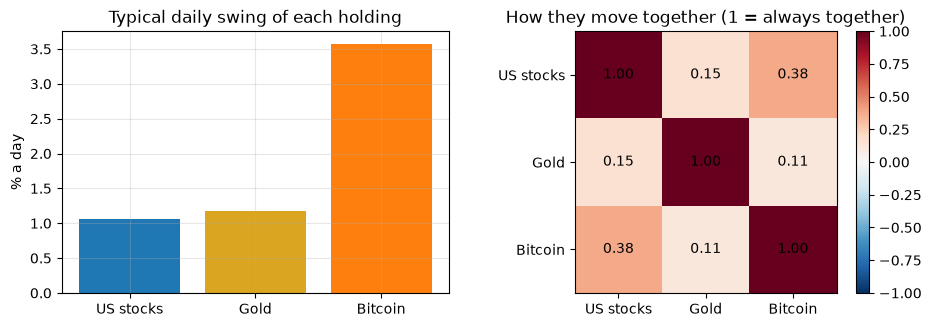

In [2]:
cov = risk.covariance(returns)
spread = np.sqrt(np.diag(cov))
fitted = LedoitWolf().fit(returns.to_numpy())
print(f"Pulled {fitted.shrinkage_:.1%} of the way towards the plain table")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.4))
left.bar([NAMES[s] for s in symbols], spread * 100, color=[COLOURS[s] for s in symbols])
left.set(title="Typical daily swing of each holding", ylabel="% a day")
correlation = cov / np.outer(spread, spread)
image = right.imshow(correlation, vmin=-1, vmax=1, cmap="RdBu_r")
right.set_xticks(range(3), [NAMES[s] for s in symbols])
right.set_yticks(range(3), [NAMES[s] for s in symbols])
for i in range(3):
    for j in range(3):
        right.text(j, i, f"{correlation[i, j]:.2f}", ha="center", va="center")
right.set(title="How they move together (1 = always together)")
right.grid(False)
fig.colorbar(image, ax=right);

With three holdings and more than a thousand days, the pull is tiny: the direct
measurement is already good, and shrinking changes almost nothing here. It earns its
place when the table is measured on less data, as it is each month in section 3 (250
days), and when a portfolio holds many more things.

A bigger source of uncertainty is that **the relationships themselves change**. Below
is how closely Bitcoin moved with US stocks, measured on each year separately, both
directly and after shrinking.

In [3]:
rows = []
for start in range(0, len(returns) - 250 + 1, 250):
    year = returns.iloc[start : start + 250]
    raw = np.cov(year.to_numpy(), rowvar=False)
    shrunk = LedoitWolf().fit(year.to_numpy()).covariance_
    rows.append(
        {
            "from": year.index[0].date(),
            "measured directly": raw[0, 2] / np.sqrt(raw[0, 0] * raw[2, 2]),
            "after shrinking": shrunk[0, 2] / np.sqrt(shrunk[0, 0] * shrunk[2, 2]),
        }
    )
by_year = pd.DataFrame(rows).set_index("from")
by_year

,measured directly,after shrinking
from,,
2021-01-05,0.2354,0.2086
2021-12-31,0.5851,0.5444
2022-12-29,0.1914,0.1626
2023-12-28,0.3905,0.3533
2024-12-26,0.4273,0.4014


The two columns are close, as expected. The rows are not: in some years Bitcoin moved
with stocks strongly and in others only loosely. No single number for "how they move
together" is right for every year, which is why every figure on the Portfolio screen
states the days it was measured on.

## 2. Risk by holding

Each holding's **share of the risk** answers: of all the mix's swings, how much comes
from this holding? It depends on the holding's size, how wildly it swings, and how
much it moves with the others. The shares add up to exactly 100%.

,share of money,share of risk
US stocks,0.3000,0.2972
Gold,0.1500,0.0852
Bitcoin,0.1500,0.6176
Cash,0.4000,0.0000


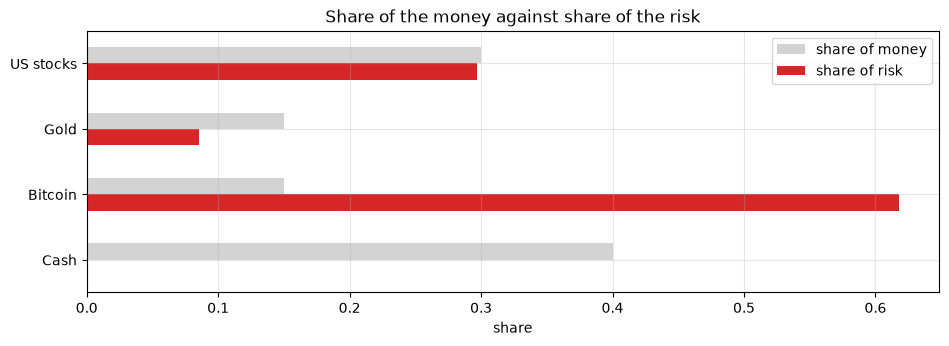

In [4]:
shares = risk.risk_shares(weights, cov)
assert abs(shares.sum() - 1.0) < 1e-9

table = pd.DataFrame(
    {
        "share of money": list(weights) + [1 - weights.sum()],
        "share of risk": list(shares) + [0.0],
    },
    index=[NAMES[s] for s in symbols] + ["Cash"],
)
ax = table.plot.barh(color=["lightgrey", "tab:red"])
ax.set(title="Share of the money against share of the risk", xlabel="share")
ax.invert_yaxis()
table

Bitcoin is 15% of the money and most of the risk. Cash is 40% of the money and none of
it. That gap is the single most useful fact about a mixed portfolio.

The mix's own daily swing, and the same holdings if they always moved together (no
benefit from mixing):

In [5]:
daily = float(np.sqrt(weights @ cov @ weights))
print(f"Typical day for the mix:        ±{daily:.2%}  (±${daily * VALUE:,.0f})")
print(f"If everything moved together:   ±{float(weights @ spread):.2%}")
print(f"US stocks alone:                ±{spread[0]:.2%}")
print(f"The mix moves {daily / spread[0]:.2f}× as much as US stocks")

Typical day for the mix:        ±0.77%  (±$77)
If everything moved together:   ±1.03%
US stocks alone:                ±1.06%
The mix moves 0.72× as much as US stocks


## 4. The value range ahead

**The question.** Where might this portfolio's value be in 30 or 90 trading days?

**The method: a block bootstrap.** A simulated future is built from real past days.

- Pick a random past day and take the **10 trading days** starting there, for all
  three holdings at once. Then pick another run of 10, and another, until the future
  is long enough.
- Let the holdings grow or shrink through those days. Nothing is rebalanced and cash
  does not move.
- Do that 10,000 times and look at where the value ends up.

**Why whole days, for every holding at once?** Because on a day stocks fell hard,
Bitcoin usually fell too. Taking the same day for all three keeps that.

**Why runs of days and not single days?** Because rough days tend to come in
clusters. The chart below measures it: how strongly the size of one day's move is
related to the size of the moves on later days. Drawing single days would shuffle any
clusters away. Whether that matters for this mix is tested in section 5.

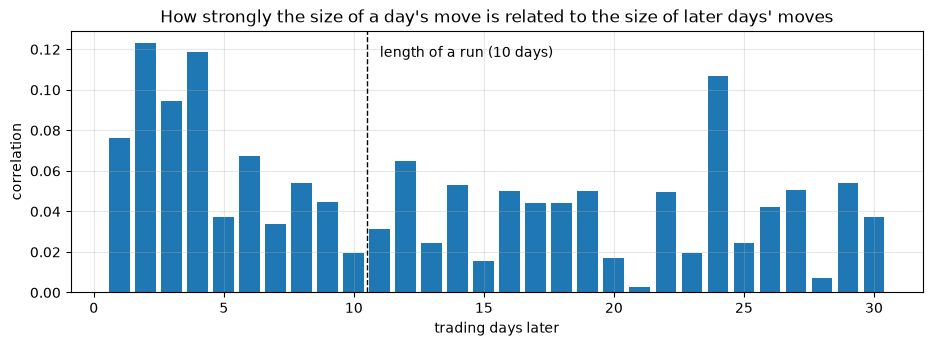

In [9]:
mix_daily = risk.mix_returns(returns, weights)
size = mix_daily.abs()
lags = range(1, 31)
fig, ax = plt.subplots()
ax.bar(lags, [size.autocorr(lag) for lag in lags], color="tab:blue")
ax.axvline(ahead.BLOCK + 0.5, color="black", linestyle="--", linewidth=1)
ax.text(ahead.BLOCK + 1, ax.get_ylim()[1] * 0.9, "length of a run (10 days)")
ax.set(
    title="How strongly the size of a day's move is related to the size of later days' moves",
    xlabel="trading days later",
    ylabel="correlation",
);

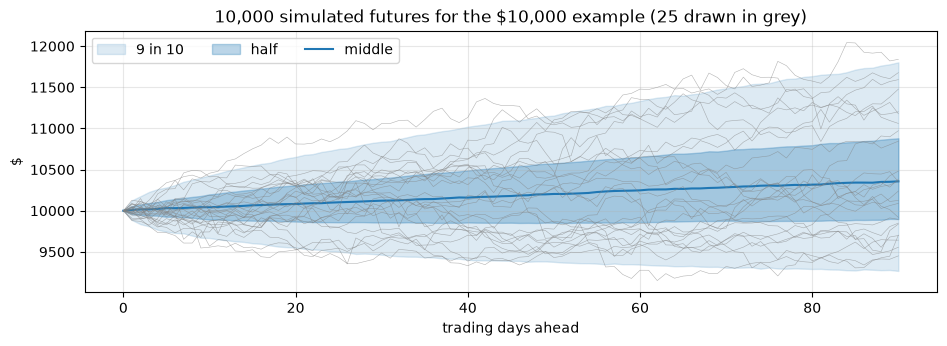

In [10]:
matrix = returns.to_numpy()
paths = ahead.simulate(matrix, weights, 90, seed=0)
fan = simulator.fan(paths, VALUE)

fig, ax = plt.subplots()
days = range(91)
ax.fill_between(days, fan["0.05"], fan["0.95"], color="tab:blue", alpha=0.15, label="9 in 10")
ax.fill_between(days, fan["0.25"], fan["0.75"], color="tab:blue", alpha=0.3, label="half")
ax.plot(days, fan["0.5"], color="tab:blue", label="middle")
for path in paths[:25]:
    ax.plot(days, [VALUE, *VALUE * np.exp(path)], color="grey", linewidth=0.4, alpha=0.6)
ax.set(title="10,000 simulated futures for the $10,000 example (25 drawn in grey)", xlabel="trading days ahead", ylabel="$")
ax.legend(loc="upper left", ncol=3);

In [11]:
stored = ahead.run(matrix, weights, VALUE)
rows = {}
for horizon in stored.horizons:
    s = horizon.summary
    eighty = next(i for i in s.intervals if i.level == 0.8)
    down5 = next(c for c in horizon.chances if c.change == -0.05)
    rows[f"{s.steps} trading days"] = {
        "middle outcome $": s.quantiles["0.5"],
        "8 in 10 end above $": eighty.low,
        "8 in 10 end below $": eighty.high,
        "typical deepest dip": s.expected_worst_drawdown,
        "chance of ending 5% down": down5.ends_beyond,
        "chance of being 5% down at some point": down5.touches,
    }
pd.DataFrame(rows).T

,middle outcome $,8 in 10 end above $,8 in 10 end below $,typical deepest dip,chance of ending 5% down,chance of being 5% down at some point
30 trading days,10121.6568,9612.3162,10670.5388,-0.0370,0.0598,0.1145
90 trading days,10356.7105,9503.8994,11438.2927,-0.0656,0.0992,0.2650


The last two columns answer different questions. Ending 5% down is rarer than being 5%
down *at some point on the way*, because some dips recover. The app lets you pick any
size of change and shows both.

## 5. Is that range any good?

A range is only worth showing if past ranges held about as often as they claimed. The
check is the same walk-forward idea as before:

- Stand at a past date. Draw a 30-day range **using only the days before it**.
- Look at what the portfolio actually did over the next 30 days.
- Move on 30 days (so no two outcomes share a day) and repeat.

If the "80% range" is honest, about 80% of outcomes should land inside it.

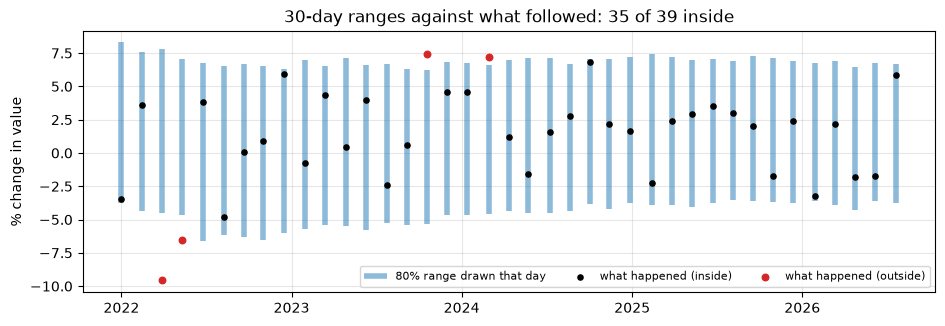

In [12]:
records = ahead.backtest(matrix, weights, 30)
dates = returns.index[[r.origin for r in records]]
low = np.array([r.bounds["0.8"][0] for r in records])
high = np.array([r.bounds["0.8"][1] for r in records])
realised = np.array([r.realised for r in records])
inside = (realised >= low) & (realised <= high)

fig, ax = plt.subplots()
ax.vlines(dates, np.expm1(low) * 100, np.expm1(high) * 100, color="tab:blue", alpha=0.5, linewidth=4, label="80% range drawn that day")
ax.scatter(dates[inside], np.expm1(realised[inside]) * 100, color="black", s=14, zorder=3, label="what happened (inside)")
ax.scatter(dates[~inside], np.expm1(realised[~inside]) * 100, color="tab:red", s=22, zorder=3, label="what happened (outside)")
ax.set(title=f"30-day ranges against what followed: {inside.sum()} of {len(records)} inside", ylabel="% change in value")
ax.legend(ncol=3, fontsize=8);

### Against simpler methods

Three ways of drawing the same range, checked on the same dates:

- **Runs of 10 days**: what the app uses.
- **Single days**: the same, but drawing one day at a time (clusters shuffled away).
- **Bell curve**: assume every day is an independent draw from a bell curve with the
  average and spread of the days so far.

The table shows how often each range held. The closer to the stated level, the better.
The last column is the average width of the 80% range: of two methods that hold equally
often, the narrower one is more useful.

In [13]:
def scorecard(records: list[ahead.PastRange]) -> dict[str, float]:
    row = {f"{c.level:.0%} range held": c.inside / c.n for c in ahead.coverage(records)}
    row["cases"] = len(records)
    row["width of the 80% range"] = float(np.mean([np.expm1(r.bounds["0.8"][1]) - np.expm1(r.bounds["0.8"][0]) for r in records]))
    return row


compared = {}
for horizon in ahead.HORIZONS:
    compared[(f"{horizon} days", "runs of 10 days")] = scorecard(ahead.backtest(matrix, weights, horizon))
    compared[(f"{horizon} days", "single days")] = scorecard(ahead.backtest(matrix, weights, horizon, block=1))
    compared[(f"{horizon} days", "bell curve")] = scorecard(ahead.normal_backtest(matrix, weights, horizon))
pd.DataFrame(compared).T

50% range held  80% range held  95% range held  \
30 days runs of 10 days          0.5128          0.8974          0.9744   
        single days              0.5128          0.8718          0.9744   
        bell curve               0.5128          0.8974          0.9744   
90 days runs of 10 days          0.5385          0.7692          0.9231   
        single days              0.6154          0.8462          0.9231   
        bell curve               0.6154          0.8462          0.8462   

                          cases  width of the 80% range  
30 days runs of 10 days 39.0000                  0.1153  
        single days     39.0000                  0.1176  
        bell curve      39.0000                  0.1167  
90 days runs of 10 days 13.0000                  0.2094  
        single days     13.0000                  0.2141  
        bell curve      13.0000                  0.2066

**The plain result: the three methods cannot be told apart.** Their ranges held about
equally often and are about equally wide. On this mix and these years, gluing runs of
real days together is not measurably more accurate than a bell curve.

Read the table with its sample size in mind, too. There are a few dozen 30-day cases
and only about a dozen 90-day ones, so a difference of one or two cases between
methods is not evidence of anything.

So why does the app use the simulation?

- It **does not assume a bell curve**. It can only produce days that really happened,
  including the worst ones, for all holdings together.
- It gives things a formula for the end point does not: **the dips on the way** and
  the chance of touching a level before the end.
- Its range is **in line with its stated level**, which is what the app grades it on:
  the count of ranges that held must be one an honest range of that level would
  plausibly produce.

The app states the bell curve's record beside the simulation's and does not claim the
simulation is more accurate.

### Does the length of a run matter?

In [14]:
by_block = {
    f"runs of {block}": scorecard(ahead.backtest(matrix, weights, 30, block=block))
    for block in (1, 5, 10, 20)
}
pd.DataFrame(by_block).T

,50% range held,80% range held,95% range held,cases,width of the 80% range
runs of 1,0.5128,0.8718,0.9744,39.0000,0.1176
runs of 5,0.5128,0.8974,0.9744,39.0000,0.1130
runs of 10,0.5128,0.8974,0.9744,39.0000,0.1153
runs of 20,0.5128,0.8974,0.9744,39.0000,0.1175


The answer barely moves with the length of the run. That is reassuring in one way:
the result does not hinge on the one number that was picked by judgement. It also
agrees with the table above: for this mix, keeping clusters of rough days together
makes little difference at these horizons.

### The no-lookahead check

A range drawn at a past date must not change if later days change.

In [15]:
tampered = matrix.copy()
tampered[700:] = 0.5
again = ahead.backtest(tampered, weights, 30)
unchanged = [a.bounds == b.bounds for a, b in zip(records, again) if a.origin <= 700]
assert all(unchanged)
print(f"{len(unchanged)} ranges drawn up to day 700 are identical after rewriting every later day")

16 ranges drawn up to day 700 are identical after rewriting every later day


## What these models cannot tell you

- **Everything here is drawn from the past few years.** A future unlike anything in
  them (a crash deeper than any in the data, or holdings that stop moving together the
  way they have) is not in the range.
- **The simulated range has not beaten a bell curve.** It is calibrated, and it is
  kept for what else it gives, but it is not a more accurate range on this data.
- **Sample sizes are small for the long horizon.** About a dozen separate 90-day
  periods fit in the data. The 30-day check rests on a few dozen.
- **Holdings with a short price record** (a newly listed coin or stock) cannot be drawn
  from. In the app their risk is estimated from the days they have and every outcome
  is widened to allow for them; the screen says when that has been done.

---

# Part 2. Paying in regularly

# Regular buying: where might a plan of equal purchases end up?

**Regular buying** (often called dollar-cost averaging, or DCA) means putting in the
same amount on a schedule, for example $100 every month, whatever the price is that
day. This notebook shows how RADAR simulates such a plan, how it compares with putting
the same total in all at once, and how far the result can be trusted.

**The example used here is made up:** $100 every month for a year, 60% into US stocks
and 40% into Bitcoin.

Rebuild with `uv run python backend/scripts/build_notebooks.py 09_regular_buying`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from radar.db.session import make_engine, session_scope
from radar.models import regular_buying as dca
from radar.models.portfolio_simulation import sample_days
from radar.pipelines.datasets import build_mixed_panel
from radar.universe import get_universe

plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
engine, universe = make_engine(), get_universe()

SPLIT = {"SPY": 0.6, "BTC/USD": 0.4}
AMOUNT, EVERY, PURCHASES = 100.0, 21, 12  # $100, every 21 trading days (a month), 12 times
symbols = list(SPLIT)
weights = np.array([SPLIT[s] for s in symbols])

with session_scope(engine) as session:
    panel = build_mixed_panel(session, universe)
joint = panel.returns[symbols].dropna()
returns = joint.to_numpy()
sessions = EVERY * PURCHASES
print(f"{len(joint):,} trading days of prices, {joint.index[0].date()} to {joint.index[-1].date()}")
print(f"The plan: {PURCHASES} purchases of ${AMOUNT:,.0f}, ${AMOUNT * PURCHASES:,.0f} in all, over {sessions} trading days")

1,444 trading days of prices, 2021-01-05 to 2026-10-05
The plan: 12 purchases of $100, $1,200 in all, over 252 trading days


## 1. One simulated future, step by step

A simulated future is built from real past days: runs of 10 trading days in a row,
picked at random and joined end to end, taken for both assets at once so that days on
which they fell together stay together (the same method as the portfolio's range
ahead, notebook 07).

Along that future the plan buys $100 at the start of each month and never sells. The
dashed line is the money paid in so far; the solid line is what the holdings are worth.

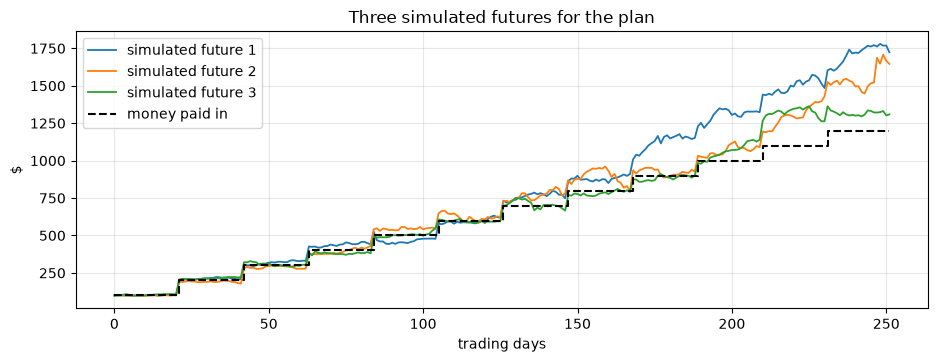

In [2]:
rng = np.random.default_rng(1)
picked = sample_days(len(returns), sessions, 3, 10, rng)
plan, lump = dca.run_plan(returns[picked], weights, AMOUNT, EVERY, PURCHASES)
paid = AMOUNT * (np.arange(sessions) // EVERY + 1)

fig, ax = plt.subplots()
for i, colour in enumerate(("tab:blue", "tab:orange", "tab:green")):
    ax.plot(plan[i], color=colour, linewidth=1.3, label=f"simulated future {i + 1}")
ax.step(range(sessions), paid, where="post", color="black", linestyle="--", label="money paid in")
ax.set(title="Three simulated futures for the plan", xlabel="trading days", ylabel="$")
ax.legend();

## 2. Thousands of futures

Repeat that 5,000 times and look at the spread of outcomes.

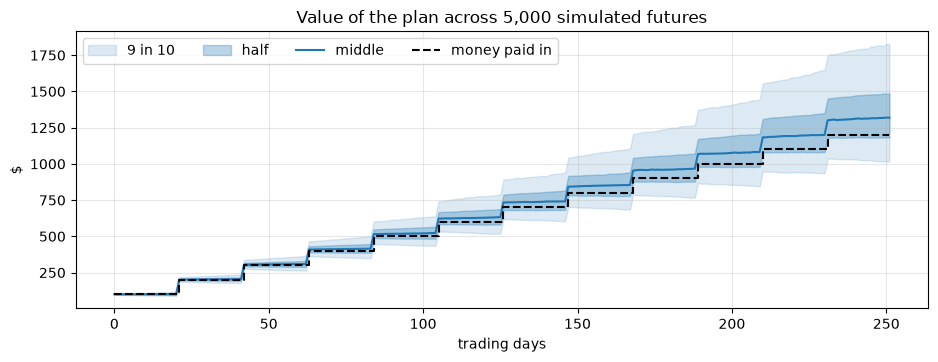

In [3]:
result = dca.run(returns, weights, AMOUNT, EVERY, PURCHASES)
days = range(sessions)
fig, ax = plt.subplots()
ax.fill_between(days, result.fan["0.05"], result.fan["0.95"], color="tab:blue", alpha=0.15, label="9 in 10")
ax.fill_between(days, result.fan["0.25"], result.fan["0.75"], color="tab:blue", alpha=0.3, label="half")
ax.plot(days, result.fan["0.5"], color="tab:blue", label="middle")
ax.step(days, result.paid_in_path, where="post", color="black", linestyle="--", label="money paid in")
ax.set(title="Value of the plan across 5,000 simulated futures", xlabel="trading days", ylabel="$")
ax.legend(loc="upper left", ncol=4);

In [4]:
summary = pd.DataFrame(
    {
        "buying bit by bit": {**result.plan.quantiles, "ends below what was paid in": result.plan.below_paid_in},
        "all at once on day one": {**result.at_once.quantiles, "ends below what was paid in": result.at_once.below_paid_in},
    }
).rename(index={"0.05": "bad outcome (1 in 20)", "0.25": "lower quarter", "0.5": "middle", "0.75": "upper quarter", "0.95": "good outcome (1 in 20)"})
print(f"Paid in: ${result.paid_in:,.0f}")
print(f"Buying bit by bit ended with more in {result.plan_ahead:.0%} of the futures")
summary

Paid in: $1,200
Buying bit by bit ended with more in 32% of the futures


,buying bit by bit,all at once on day one
bad outcome (1 in 20),"1,016.90",936.59
lower quarter,"1,182.32","1,187.57"
middle,"1,318.73","1,412.72"
upper quarter,"1,485.84","1,702.97"
good outcome (1 in 20),"1,827.23","2,391.28"
ends below what was paid in,0.28,0.27


## 3. Bit by bit against all at once

The same total, put in on the first day, is run through **the very same futures**, so
the comparison is like for like.

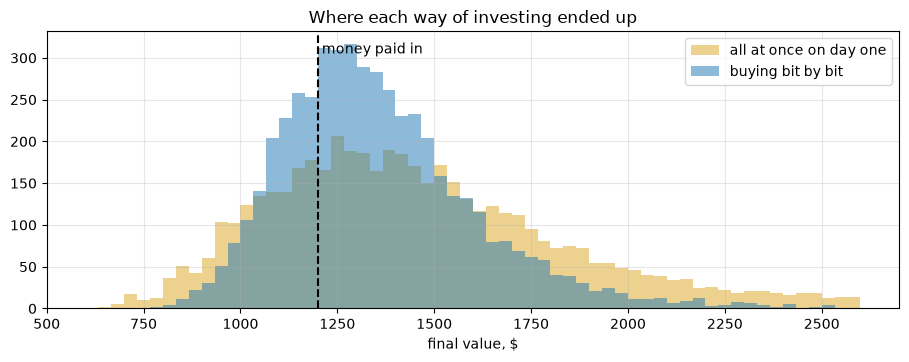

In [5]:
plan_all, lump_all = dca.simulate(returns, weights, AMOUNT, EVERY, PURCHASES)
fig, ax = plt.subplots()
bins = np.linspace(600, 2600, 61)
ax.hist(lump_all[:, -1], bins=bins, alpha=0.5, color="goldenrod", label="all at once on day one")
ax.hist(plan_all[:, -1], bins=bins, alpha=0.5, color="tab:blue", label="buying bit by bit")
ax.axvline(result.paid_in, color="black", linestyle="--")
ax.text(result.paid_in + 10, ax.get_ylim()[1] * 0.92, "money paid in")
ax.set(title="Where each way of investing ended up", xlabel="final value, $")
ax.legend();

What the picture shows is a trade, not a winner:

- **All at once is wider.** The money is in the market for the whole year, so it has
  more time to grow and more time to fall. Its good outcomes are better and its bad
  outcomes are worse.
- **Bit by bit is narrower.** On average half the money is still waiting to go in, so
  less is at risk at any moment. The price of that is giving up some of the growth
  when markets rise, which over these years they mostly did.

Regular buying is a way of taking less risk early on. It is not a way of getting a
better price: the table above shows how often it ended ahead.

## 4. How far can this be trusted?

The same walk-forward check as every other range in RADAR: stand at a past date,
simulate the plan **from the days before it only**, then run the real plan through the
days that followed and see whether it landed inside the range. The starts are a full
plan apart so no two share a day.

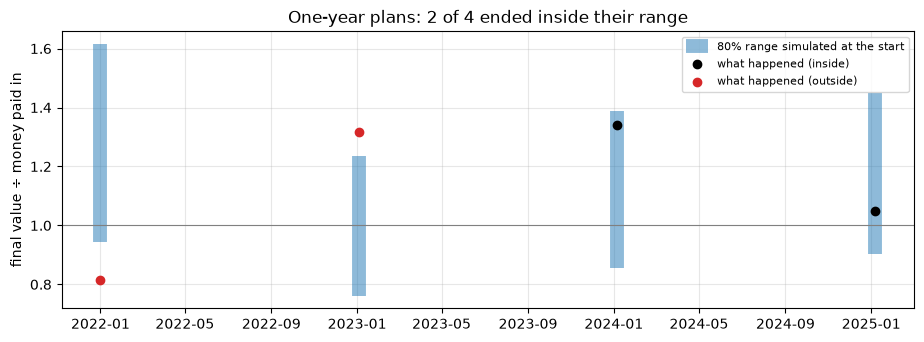

In [6]:
records = dca.backtest(returns, weights, EVERY, PURCHASES)
starts = joint.index[[r.origin for r in records]]
fig, ax = plt.subplots()
low = np.array([r.bounds["0.8"][0] for r in records])
high = np.array([r.bounds["0.8"][1] for r in records])
realised = np.array([r.realised for r in records])
inside = (realised >= low) & (realised <= high)
ax.vlines(starts, low, high, color="tab:blue", alpha=0.5, linewidth=10, label="80% range simulated at the start")
ax.scatter(starts[inside], realised[inside], color="black", zorder=3, label="what happened (inside)")
ax.scatter(starts[~inside], realised[~inside], color="tab:red", zorder=3, label="what happened (outside)")
ax.axhline(1.0, color="grey", linewidth=0.8)
ax.set(title=f"One-year plans: {inside.sum()} of {len(records)} ended inside their range", ylabel="final value ÷ money paid in")
ax.legend(fontsize=8);

**There are very few cases.** Only a handful of separate one-year stretches fit in the
stored prices, so this check can catch a method that is badly wrong but cannot confirm
one that is right. Shorter plans can be checked more times:

In [7]:
rows = {}
for label, every, purchases in (("3 months, monthly", 21, 3), ("6 months, monthly", 21, 6), ("1 year, monthly", 21, 12), ("1 year, weekly", 5, 50), ("2 years, monthly", 21, 24)):
    found = dca.coverage(dca.backtest(returns, weights, every, purchases))
    rows[label] = {"past cases": found[0].n, **{f"{c.level:.0%} range held": f"{c.inside} of {c.n}" for c in found}}
pd.DataFrame(rows).T

,past cases,50% range held,80% range held,95% range held
"3 months, monthly",18,10 of 18,13 of 18,17 of 18
"6 months, monthly",9,4 of 9,7 of 9,8 of 9
"1 year, monthly",4,1 of 4,2 of 4,3 of 4
"1 year, weekly",4,1 of 4,2 of 4,3 of 4
"2 years, monthly",2,2 of 2,2 of 2,2 of 2


### The no-lookahead check

A range simulated at a past date must not change if later days change.

In [8]:
tampered = returns.copy()
tampered[800:] = 0.3
again = dca.backtest(tampered, weights, EVERY, PURCHASES)
unchanged = [a.bounds == b.bounds for a, b in zip(records, again) if a.origin <= 800]
assert all(unchanged)
print(f"{len(unchanged)} past ranges are identical after rewriting every day from row 800 on")

3 past ranges are identical after rewriting every day from row 800 on


## What this cannot tell you

- **It rests on a few years.** Every simulated future is stitched from the stored
  days. A year unlike any of them, better or worse, is not in the range. The longer the
  plan, the fewer separate stretches of that length exist to learn from, which is why
  the app caps a plan at two years and says how many stretches there were.
- **Trading costs and taxes are left out**, and a purchase is assumed to happen at the
  day's closing price.
- **It describes a plan, not a decision.** Whether to buy bit by bit or at once depends
  on how much a fall early on would matter to the person, which no simulation knows.